In [5]:
import pandas as pd
import sqlite3
from pathlib import Path
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)

DATA_DIR = Path.cwd()
BOOKS_CSV = DATA_DIR / "Books.csv"
RATINGS_CSV = DATA_DIR / "Ratings.csv"
USERS_CSV = DATA_DIR / "Users.csv"

DB_PATH = DATA_DIR / "books.db"

books = pd.read_csv(BOOKS_CSV, low_memory=False)
ratings = pd.read_csv(RATINGS_CSV, low_memory=False)
users = pd.read_csv(USERS_CSV, low_memory=False)





In [6]:
books.head()

,ISBN,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L
0,0195153448,Classical Mythology,Mark P. O. Morford,2002,Oxford University Press,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...
1,0002005018,Clara Callan,Richard Bruce Wright,2001,HarperFlamingo Canada,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...
2,0060973129,Decision in Normandy,Carlo D'Este,1991,HarperPerennial,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...
3,0374157065,Flu: The Story of the Great Influenza Pandemic...,Gina Bari Kolata,1999,Farrar Straus Giroux,http://images.amazon.com/images/P/0374157065.0...,http://images.amazon.com/images/P/0374157065.0...,http://images.amazon.com/images/P/0374157065.0...
4,0393045218,The Mummies of Urumchi,E. J. W. Barber,1999,W. W. Norton &amp; Company,http://images.amazon.com/images/P/0393045218.0...,http://images.amazon.com/images/P/0393045218.0...,http://images.amazon.com/images/P/0393045218.0...


In [7]:
ratings.head()

,User-ID,ISBN,Book-Rating
0,276725,034545104X,0
1,276726,0155061224,5
2,276727,0446520802,0
3,276729,052165615X,3
4,276729,0521795028,6


In [8]:
users.head()

,User-ID,Location,Age
0,1,"nyc, new york, usa",NaN
1,2,"stockton, california, usa",18.0
2,3,"moscow, yukon territory, russia",NaN
3,4,"porto, v.n.gaia, portugal",17.0
4,5,"farnborough, hants, united kingdom",NaN


In [9]:
users["Age"] = pd.to_numeric(users['Age'], errors='coerce')

users.loc[(users["Age"] < 5) | (users['Age'] > 100), 'Age'] = pd.NA

for col in ["Location"]:
    if col in users.columns:
        users[col] = users[col].astype(str).str.strip().replace({'': pd.NA, 'NaN': pd.NA})

if 'User-ID' in users.columns:
    users = users.drop_duplicates(subset=["User-ID"])
else:
    users = users.drop_duplicates()

users.head(), users["Age"].describe()

(   User-ID                            Location   Age
 0        1                  nyc, new york, usa   NaN
 1        2           stockton, california, usa  18.0
 2        3     moscow, yukon territory, russia   NaN
 3        4           porto, v.n.gaia, portugal  17.0
 4        5  farnborough, hants, united kingdom   NaN,
 count    166848.000000
 mean         34.746638
 std          13.633051
 min           5.000000
 25%          24.000000
 50%          32.000000
 75%          44.000000
 max         100.000000
 Name: Age, dtype: float64)

In [10]:
users['Age'].isna().sum(), len(users)

users.loc[users['Age'].isna()].head(10)

,User-ID,Location,Age
0,1,"nyc, new york, usa",NaN
2,3,"moscow, yukon territory, russia",NaN
4,5,"farnborough, hants, united kingdom",NaN
6,7,"washington, dc, usa",NaN
7,8,"timmins, ontario, canada",NaN
8,9,"germantown, tennessee, usa",NaN
11,12,"fort bragg, california, usa",NaN
13,14,"mediapolis, iowa, usa",NaN
14,15,"calgary, alberta, canada",NaN
15,16,"albuquerque, new mexico, usa",NaN


In [11]:
ratings.head()

,User-ID,ISBN,Book-Rating
0,276725,034545104X,0
1,276726,0155061224,5
2,276727,0446520802,0
3,276729,052165615X,3
4,276729,0521795028,6


In [17]:
ratings['Book-Rating'] = pd.to_numeric(ratings['Book-Rating'], errors="coerce")
ratings = ratings[ratings['Book-Rating'].notna()]
ratings["Book-Rating"] = ratings["Book-Rating"].clip(lower=0, upper=10).astype("Int16")

for key in ['User-ID', 'ISBN']:
    if key in ratings.columns:
        ratings = ratings[ratings[key].notna() & (ratings[key].astype(str).str.strip() != '')]

ratings["ISBN"] = ratings["ISBN"].astype(str).str.strip()

if set(['User-ID','ISBN']).issubset(ratings.columns):
    ratings = ratings.drop_duplicates(subset=['User-ID', 'ISBN', 'Book-Rating'])
else:
    ratings = ratings.drop_duplicates()

ratings.head()

,User-ID,ISBN,Book-Rating
0,276725,034545104X,0
1,276726,0155061224,5
2,276727,0446520802,0
3,276729,052165615X,3
4,276729,0521795028,6


In [18]:
books.head()

,ISBN,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L
0,0195153448,Classical Mythology,Mark P. O. Morford,2002,Oxford University Press,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...
1,0002005018,Clara Callan,Richard Bruce Wright,2001,HarperFlamingo Canada,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...
2,0060973129,Decision in Normandy,Carlo D'Este,1991,HarperPerennial,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...
3,0374157065,Flu: The Story of the Great Influenza Pandemic...,Gina Bari Kolata,1999,Farrar Straus Giroux,http://images.amazon.com/images/P/0374157065.0...,http://images.amazon.com/images/P/0374157065.0...,http://images.amazon.com/images/P/0374157065.0...
4,0393045218,The Mummies of Urumchi,E. J. W. Barber,1999,W. W. Norton &amp; Company,http://images.amazon.com/images/P/0393045218.0...,http://images.amazon.com/images/P/0393045218.0...,http://images.amazon.com/images/P/0393045218.0...


In [19]:
books["ISBN"] = books["ISBN"].astype(str).str.strip()
books = books[books["ISBN"].notna() & (books['ISBN'] != '')]

if 'Year-Of-Publication' in books.columns:
    books['Year-Of-Publication'] = pd.to_numeric(books['Year-Of-Publication'], errors='coerce')
    books.loc[
        (books['Year-Of-Publication'] < 1450) | (books['Year-Of-Publication'] > 2025),
        'Year-Of-Publication'
    ] = pd.NA

for col in ['Book-Title', 'Book-Author', 'Publisher']:
    if col in books.columns:
        books[col] = books[col].astype(str).str.strip().replace({'': pd.NA, 'nan': pd.NA})

books = books.drop_duplicates(subset=['ISBN'])

books.head()

,ISBN,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L
0,0195153448,Classical Mythology,Mark P. O. Morford,2002.0,Oxford University Press,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...
1,0002005018,Clara Callan,Richard Bruce Wright,2001.0,HarperFlamingo Canada,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...
2,0060973129,Decision in Normandy,Carlo D'Este,1991.0,HarperPerennial,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...
3,0374157065,Flu: The Story of the Great Influenza Pandemic...,Gina Bari Kolata,1999.0,Farrar Straus Giroux,http://images.amazon.com/images/P/0374157065.0...,http://images.amazon.com/images/P/0374157065.0...,http://images.amazon.com/images/P/0374157065.0...
4,0393045218,The Mummies of Urumchi,E. J. W. Barber,1999.0,W. W. Norton &amp; Company,http://images.amazon.com/images/P/0393045218.0...,http://images.amazon.com/images/P/0393045218.0...,http://images.amazon.com/images/P/0393045218.0...


In [21]:
connection = sqlite3.connect(DB_PATH)

books.to_sql("books", connection, if_exists="replace", index=False)
ratings.to_sql("ratings", connection, if_exists="replace", index=False)
users.to_sql("users", connection, if_exists="replace", index=False)

cur = connection.cursor()
cur.execute('CREATE INDEX IF NOT EXISTS idx_books_isbn   ON books("ISBN");')
cur.execute('CREATE INDEX IF NOT EXISTS idx_ratings_isbn ON ratings("ISBN");')
cur.execute('CREATE INDEX IF NOT EXISTS idx_ratings_user ON ratings("User-ID");')
cur.execute('CREATE INDEX IF NOT EXISTS idx_users_user   ON users("User-ID");')
connection.commit()

print("Tables written to", DB_PATH)

Tables written to /Users/jade/Desktop/REPOS/ai_machine_learning/week_4/week_4_project/books.db


In [ ]:
def sql(query: str, params: tuple | None = None) -> pd.DataFrame:
    return pd.read_sql_query(query, connection, params=params)


sql("""
SELECT 'books'   AS table_name, COUNT(*) AS rows FROM books
UNION ALL
SELECT 'ratings', COUNT(*) FROM ratings
UNION ALL
SELECT 'users',   COUNT(*) FROM users;
""")

,table_name,rows
0,books,271359
1,ratings,1149780
2,users,278858


In [23]:
def sql_print(query: str, params: tuple | None = None, head: int = 5) -> pd.DataFrame:
    
    print("Running SQL query:\n", query.strip(), "\n")
    df = pd.read_sql_query(query, connection, params=params)
    print("Rows returned:", len(df))
    print(df.head(head))
    return df

In [24]:
top_books = sql_print("""
    SELECT b.ISBN,
           b."Book-Title" AS title,
           COUNT(*) AS n_ratings,
           AVG(r."Book-Rating") AS avg_rating
    FROM ratings r
    JOIN books b ON b.ISBN = r.ISBN
    GROUP BY b.ISBN, title
    HAVING COUNT(*) >= 50
    ORDER BY n_ratings DESC
    LIMIT 10;
""")

Running SQL query:
 SELECT b.ISBN,
           b."Book-Title" AS title,
           COUNT(*) AS n_ratings,
           AVG(r."Book-Rating") AS avg_rating
    FROM ratings r
    JOIN books b ON b.ISBN = r.ISBN
    GROUP BY b.ISBN, title
    HAVING COUNT(*) >= 50
    ORDER BY n_ratings DESC
    LIMIT 10; 

Rows returned: 10
         ISBN                                            title  n_ratings  \
0  0971880107                                      Wild Animus       2502   
1  0316666343                        The Lovely Bones: A Novel       1295   
2  0385504209                                The Da Vinci Code        883   
3  0060928336  Divine Secrets of the Ya-Ya Sisterhood: A Novel        732   
4  0312195516              The Red Tent (Bestselling Backlist)        723   

   avg_rating  
0    1.019584  
1    4.468726  
2    4.652322  
3    3.448087  
4    4.334716  


In [25]:
avg_by_author = sql_print("""
    SELECT b."Book-Author" AS author,
           COUNT(*) AS n_ratings,
           AVG(r."Book-Rating") AS avg_rating
    FROM ratings r
    JOIN books b ON b.ISBN = r.ISBN
    GROUP BY author
    HAVING COUNT(*) >= 100
    ORDER BY avg_rating DESC, n_ratings DESC
    LIMIT 10;
""")
avg_by_author

Running SQL query:
 SELECT b."Book-Author" AS author,
           COUNT(*) AS n_ratings,
           AVG(r."Book-Rating") AS avg_rating
    FROM ratings r
    JOIN books b ON b.ISBN = r.ISBN
    GROUP BY author
    HAVING COUNT(*) >= 100
    ORDER BY avg_rating DESC, n_ratings DESC
    LIMIT 10; 

Rows returned: 10
                      author  n_ratings  avg_rating
0                      Clamp        150    6.513333
1           Shel Silverstein        189    6.105820
2             Bill Watterson        550    5.561818
3  Antoine de Saint-ExupÃ©ry        278    5.553957
4                      Herge        152    5.519737


,author,n_ratings,avg_rating
0,Clamp,150,6.513333
1,Shel Silverstein,189,6.105820
2,Bill Watterson,550,5.561818
3,Antoine de Saint-ExupÃ©ry,278,5.553957
4,Herge,152,5.519737
5,Bradley Trevor Greive,139,5.431655
6,J. K. Rowling,2908,5.385832
7,Nick Bantock,270,5.292593
8,J. R. R. Tolkien,978,5.165644
9,Dr. Seuss,371,5.121294


In [26]:
top_users = sql_print("""
    SELECT r."User-ID" AS user_id,
           COUNT(*) AS n_ratings
    FROM ratings r
    GROUP BY user_id
    ORDER BY n_ratings DESC
    LIMIT 10;
""")
top_users

Running SQL query:
 SELECT r."User-ID" AS user_id,
           COUNT(*) AS n_ratings
    FROM ratings r
    GROUP BY user_id
    ORDER BY n_ratings DESC
    LIMIT 10; 

Rows returned: 10
   user_id  n_ratings
0    11676      13602
1   198711       7550
2   153662       6109
3    98391       5891
4    35859       5850


,user_id,n_ratings
0,11676,13602
1,198711,7550
2,153662,6109
3,98391,5891
4,35859,5850
5,212898,4785
6,278418,4533
7,76352,3367
8,110973,3100
9,235105,3067


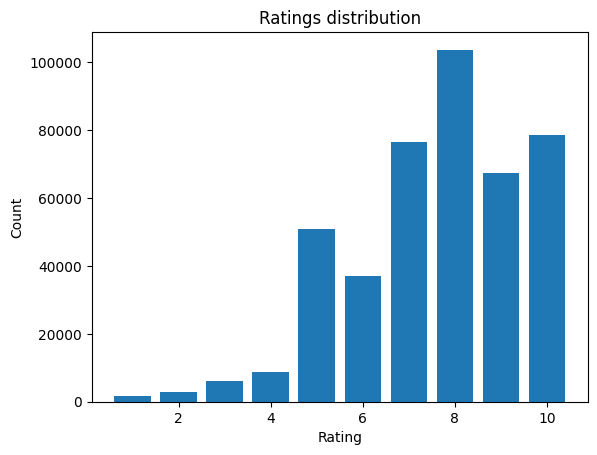

In [29]:
rating_dist['rating'] = pd.to_numeric(rating_dist['rating'], errors='coerce')

rating_dist_explicit = sql("""
    SELECT "Book-Rating" AS rating, COUNT(*) AS n
    FROM ratings
    WHERE "Book-Rating" > 0
    GROUP BY rating
    ORDER BY rating;
""")

plt.figure()
plt.bar(rating_dist_explicit['rating'], rating_dist_explicit['n'])
plt.title("Ratings distribution")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()



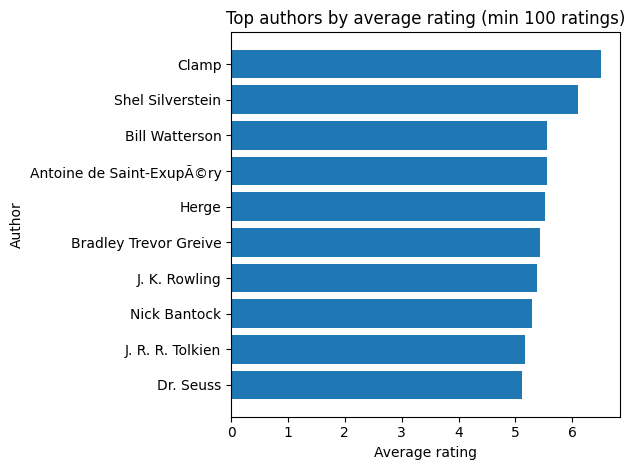

In [30]:
plt.figure()
plt.barh(avg_by_author['author'][::-1], avg_by_author['avg_rating'][::-1])
plt.title("Top authors by average rating (min 100 ratings)")
plt.xlabel("Average rating")
plt.ylabel("Author")
plt.tight_layout()
plt.show()


In [31]:
OUT_DIR = Path.cwd() / "outputs"
OUT_DIR.mkdir(exist_ok=True)

top_books.to_csv(OUT_DIR / "top_books.csv", index=False)
avg_by_author.to_csv(OUT_DIR / "avg_by_author.csv", index=False)

print(f"Saved to {OUT_DIR.resolve()}")


Saved to /Users/jade/Desktop/REPOS/ai_machine_learning/week_4/week_4_project/outputs
